In [15]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [17]:
df = pd.read_sql("""SELECT uid, timestamp FROM checker 
    WHERE uid LIKE 'user_%' AND labname = 'project1' and status = 'ready'""", conn)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

In [18]:
df_commits = df.groupby(['uid', 'date'])['timestamp'].size().reset_index(name='commits')

df_commits.head()

,uid,date,commits
0,user_1,2020-05-14,11
1,user_10,2020-05-12,7
2,user_10,2020-05-13,14
3,user_10,2020-05-14,37
4,user_11,2020-05-03,1


In [19]:
df_commits['numTrials'] = df_commits.groupby('uid')['commits'].cumsum()

In [20]:
df_commits.head()

,uid,date,commits,numTrials
0,user_1,2020-05-14,11,11
1,user_10,2020-05-12,7,7
2,user_10,2020-05-13,14,21
3,user_10,2020-05-14,37,58
4,user_11,2020-05-03,1,1


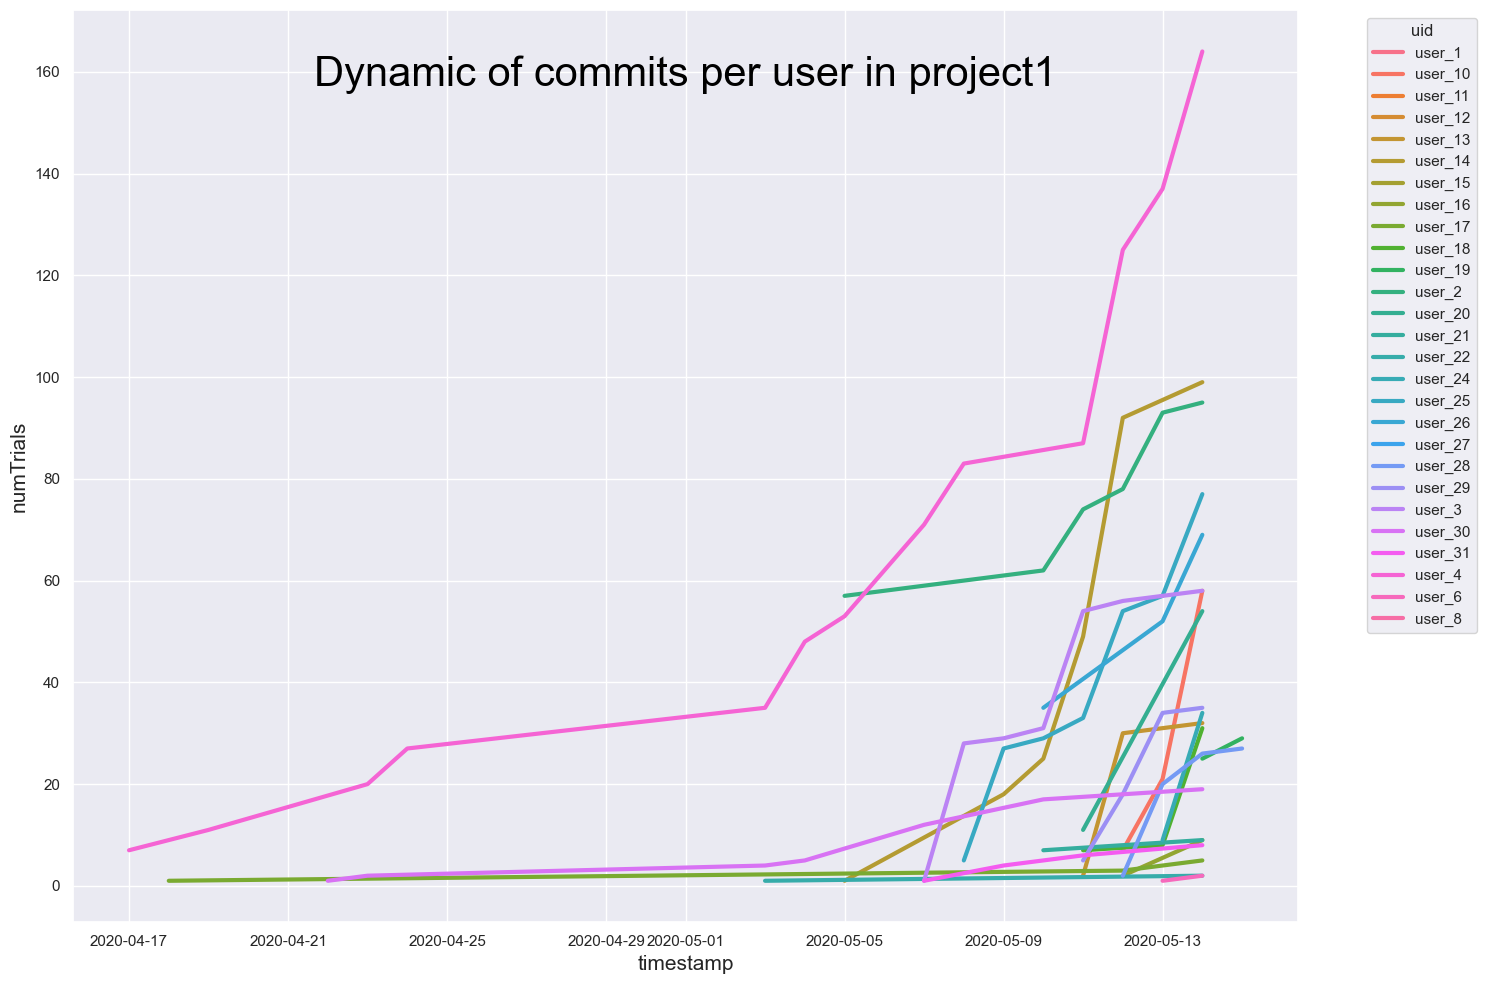

In [21]:
plt.figure(figsize=(15, 10))  # высота 10, ширина 1.5x
sns.set(style='darkgrid')
sns.set_palette('magma')

ax = sns.lineplot(
    data=df_commits,
    x='date',
    y='numTrials',
    hue='uid',
    linewidth=3
)

# подписи осей
ax.set_xlabel('timestamp', fontsize=15)
ax.set_ylabel('numTrials', fontsize=15)

# заголовок внутри графика
ax.text(
    0.5, 0.95, 'Dynamic of commits per user in project1',
    fontsize=30, ha='center', va='top', transform=ax.transAxes,
    color='black'
)

plt.legend(title='uid', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

«Какой пользователь лидировал по количеству коммитов почти всегда?» 
- Ответ: user_4.

«Какой пользователь был лидером только короткий период времени?» 
- Ответ: user_2.

In [22]:
conn.close()